#**Customer Churn Prediction**
###Customer Churn Prediction is where we predict whether a customer will leave a company or continue using its services. We use customer behavior data like tenure, charges, contract type, and services used to make this prediction.
###This helps companies take early action to retain customers and reduce revenue loss.

##**Project Objective**
###The objective of this project is to clean customer data, perform EDA, convert categorical data into numeric form, train ML classification models, and compare their performance to find the best churn prediction model.

##**Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

##**Load Dataset**

In [ ]:
df=pd.read_csv("churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##**To show the number of rows and columns**

In [ ]:
print("Rows,Columns:",df.shape)

Rows,Columns: (7043, 21)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


##**To Show Statistical Summary**

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


##**Checking missing null values**

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


###**Insight: No null values**

In [ ]:
df['TotalCharges'].dtypes

dtype('O')

##**Data preprocessing**

###**Fixing TotalCharges Column**

In [ ]:
#Checking empty strings
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [ ]:
#Replacing empty strings with NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [ ]:
#Converting from object to float using astype
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [ ]:
#Filling missing values
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

In [ ]:
df['TotalCharges'].dtypes

dtype('float64')

###**Removing Non-Useful Column**

In [ ]:
df.drop('customerID',axis=1,inplace=True)

###**Replacing the values**

In [ ]:
replace_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "MultipleLines"
]

for col in replace_cols:
    df[col] = df[col].replace({
        "No internet service": "No",
        "No phone service": "No"
    })

##**EDA**

In [ ]:
cat_col=df.select_dtypes(include=['O']).columns
cat_col

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [ ]:
num_col=df.select_dtypes(include=['int','float']).columns
num_col

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

### **1. Categorical Feature EDA**

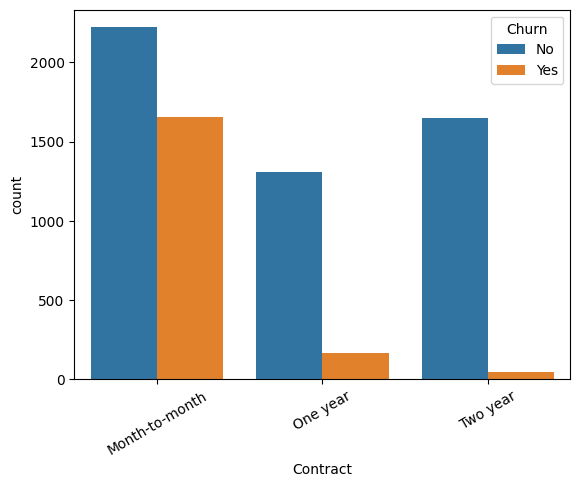

In [ ]:
sns.countplot(x="Contract",hue="Churn",data=df)
plt.xticks(rotation=30)
plt.show()

####**Insight: Month-to-month customers have the highest churn, while one-year and especially two-year contracts show much lower churn.**

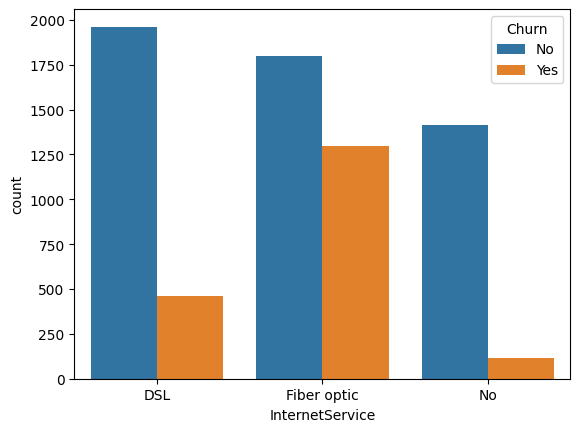

In [ ]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.show()

####**Insight:Customers with fiber optic service show the highest churn, while those with no internet service churn the least.**

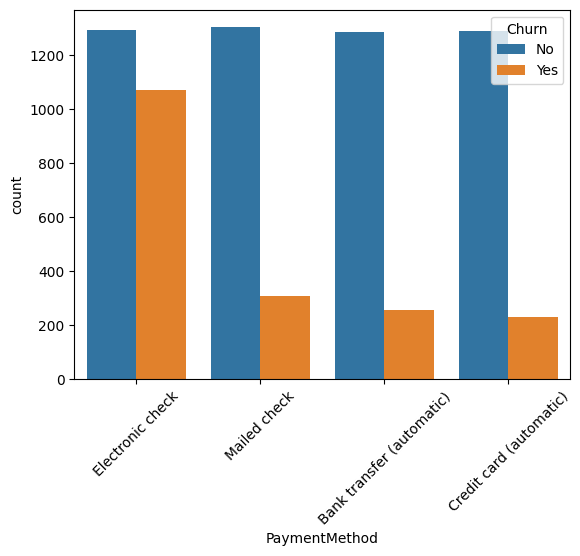

In [ ]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=45)
plt.show()

####**Insight: Electronic check users show highest churn count compared to automatic payment methods.**

###**2. Numeric Feature EDA**

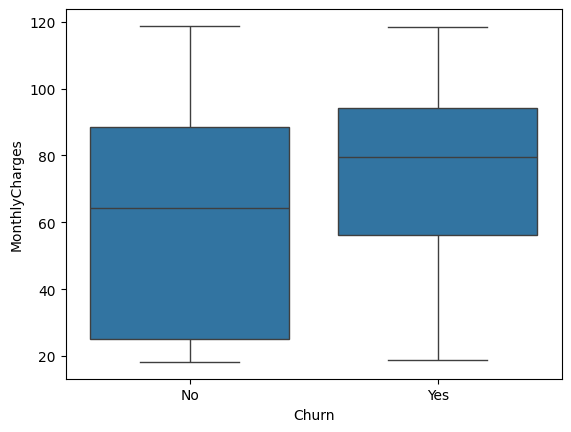

In [ ]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

####**Insight: Customers who churn have higher median MonthlyCharges compared to non-churn customers.**

###**3. Correlation Heatmap**

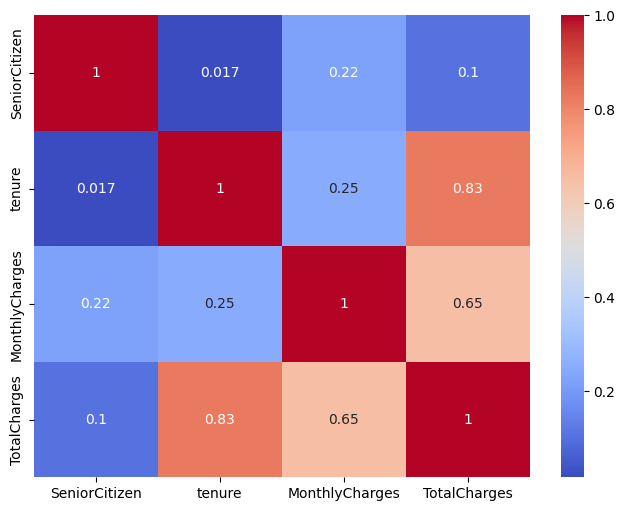

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
annot=True, cmap="coolwarm")
plt.show()

####**Insight: Tenure and TotalCharges show strong positive correlation (~0.83)customers staying longer naturally pay higher total charges.**


###**4. Target distribution**

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


<Axes: xlabel='Churn', ylabel='count'>

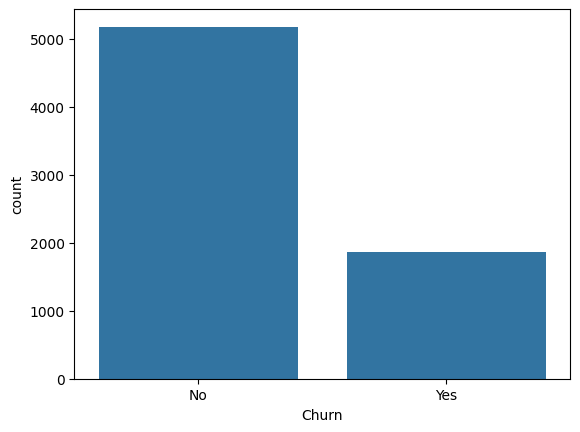

In [ ]:
sns.countplot(x="Churn",data=df)

####**Insight: Most customers do not churn, but a noticeable portion does, showing a class imbalance toward non-churners**.

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

##**Encoding Strategy**

###**1. Label Encoding**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
binary_cols = ["Partner","Dependents","PhoneService","PaperlessBilling","Churn"]
for col in binary_cols:
    df[col] = df[col].map({"Yes":1, "No":0})

df["gender"] = df["gender"].map({"Male":1, "Female":0})


In [ ]:
print(df.select_dtypes(include="object").columns)

Index(['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaymentMethod'],
      dtype='object')


###**2. One-Hot Encoding**

In [ ]:
# Spliting the target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# One hot encoding on features
X = pd.get_dummies(X, drop_first=True)


####**Insight: We convert categorical columns into numeric using Label Encoding and One-Hot Encoding. ML models only accept numbers.**

In [ ]:
#It prints percentage of each class
print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
print(y.value_counts(normalize=True))

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


##**Split the data into 80% training and 20% testing**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

#**Scaling**


###**Scaling standardizes feature ranges so Logistic Regression learns properly and it prevents large-value features dominating.**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import joblib
joblib.dump(scaler,"Scaler.pkl")

['Scaler.pkl']

#**LogisticRegression**

###**This model learns a linear relationship between features and churn probability and it gives a strong baseline classifier.**

##**Create and Train the model**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=300, class_weight="balanced")

# Train model
log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=300)

In [ ]:
# Train prediction
log_train_pred = log_model.predict(X_train_scaled)

print("\nTrain Classification Report:")
print(classification_report(y_train, log_train_pred))
print("\nLogistic Train Accuracy:", accuracy_score(y_train, log_train_pred))

# Test prediction
log_pred = log_model.predict(X_test_scaled)

print("\nTest Classification Report:")
print(classification_report(y_test, log_pred))
print("Logistic Test Accuracy:", accuracy_score(y_test, log_pred))


Train Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      4139
           1       0.52      0.81      0.63      1495

    accuracy                           0.75      5634
   macro avg       0.72      0.77      0.72      5634
weighted avg       0.81      0.75      0.76      5634


Logistic Train Accuracy: 0.751863684771033

Test Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Logistic Test Accuracy: 0.7402413058907026


#**Decision Tree**

###**This model creates rule-based splits to classify churn and easy to visualize**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_model = DecisionTreeClassifier(max_depth=6,random_state=42,class_weight="balanced")

#Trainig the model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42)

In [ ]:
# Train prediction
dt_train_pred = dt_model.predict(X_train)

print("\nTrain Classification Report:")
print(classification_report(y_train, dt_train_pred))

# Test prediction
dt_pred = dt_model.predict(X_test)

print("\nTest Classification Report:")
print(classification_report(y_test, dt_pred))


Train Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.71      0.81      4139
           1       0.52      0.85      0.64      1495

    accuracy                           0.75      5634
   macro avg       0.72      0.78      0.73      5634
weighted avg       0.82      0.75      0.76      5634


Test Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.71      0.80      1035
           1       0.50      0.82      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.74      0.75      1409



#**Random Forest**

###**This builds many trees and combines them for better accuracy and less overfitting, it more stable than single tree.**


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
rf_model = RandomForestClassifier(n_estimators=200,max_depth=8,class_weight="balanced",random_state=42)

#Training the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, n_estimators=200,
                       random_state=42)

In [ ]:
# Train prediction
rf_train_pred = rf_model.predict(X_train)

print("\nTrain Classification Report:")
print(classification_report(y_train, rf_train_pred))

# Test prediction
rf_pred = rf_model.predict(X_test)

print("\nTest Classification Report:")
print(classification_report(y_test, rf_pred))


Train Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.79      0.86      4139
           1       0.60      0.85      0.70      1495

    accuracy                           0.81      5634
   macro avg       0.77      0.82      0.78      5634
weighted avg       0.84      0.81      0.82      5634


Test Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.76      0.83      1035
           1       0.54      0.77      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.78      1409



##**Comparison between models**

In [ ]:
from sklearn.metrics import recall_score, f1_score

print("Model | Accuracy | Recall(Churn=1) | F1")

print("Logistic:",
      accuracy_score(y_test, log_pred),
      recall_score(y_test, log_pred),
      f1_score(y_test, log_pred))

print("Decision Tree:",
      accuracy_score(y_test, dt_pred),
      recall_score(y_test, dt_pred),
      f1_score(y_test, dt_pred))

print("Random Forest:",
      accuracy_score(y_test, rf_pred),
      recall_score(y_test, rf_pred),
      f1_score(y_test, rf_pred))

Model | Accuracy | Recall(Churn=1) | F1
Logistic: 0.7402413058907026 0.786096256684492 0.6163522012578616
Decision Tree: 0.7381121362668559 0.8181818181818182 0.6238532110091743
Random Forest: 0.7643718949609652 0.7727272727272727 0.6351648351648351


#**Model Evaluation**

###**Model evaluation is the process of measuring how well a trained machine learning model performs on unseen data.**

In [ ]:
#Best Model is Random Forest.
#Evaluation based on Best Model

from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

[[788 247]
 [ 85 289]]
              precision    recall  f1-score   support

           0       0.90      0.76      0.83      1035
           1       0.54      0.77      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.78      1409



#**Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [6, 8, 10],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid,
    cv=3,
    scoring="recall",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Recall:", grid.best_score_)

best_rf = grid.best_estimator_

rf_pred = best_rf.predict(X_test)
#Accuracy score
print("Tuned RF Accuracy:", accuracy_score(y_test, rf_pred))

Best Params: {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Recall: 0.7913122094255445
Tuned RF Accuracy: 0.7473385379701917


#**Cross Validation**

In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5)
print("CV Mean:", cv_scores.mean())

CV Mean: 0.7559398645549809


# **Feature Importance**

###**Shows which features most influence churn prediction and it converts model into business insight.**

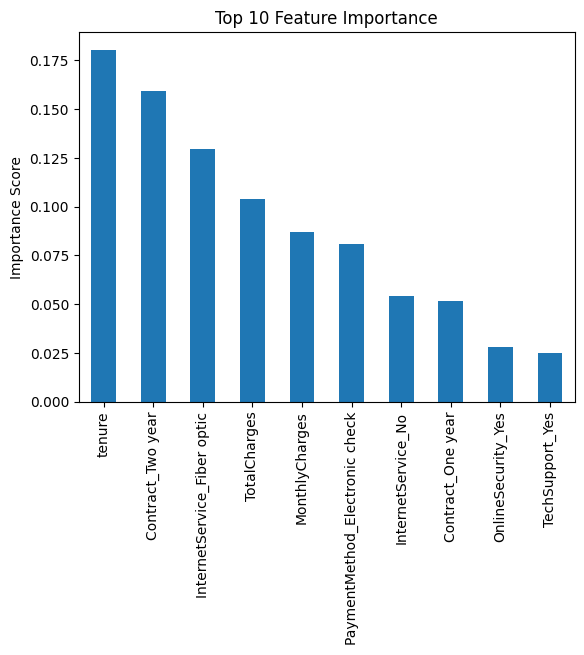

In [ ]:
imp = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
imp.plot(kind="bar")
plt.title("Top 10 Feature Importance")
plt.ylabel("Importance Score")
plt.show()



In [ ]:
grid.best_estimator_

RandomForestClassifier(class_weight='balanced', max_depth=6,
                       min_samples_split=5, n_estimators=200, random_state=42)

In [ ]:
#Final Model
final_model=grid.best_estimator_

In [ ]:
final_model

RandomForestClassifier(class_weight='balanced', max_depth=6,
                       min_samples_split=5, n_estimators=200, random_state=42)

In [ ]:
import joblib
joblib.dump(final_model,"Churn_model.pkl")
joblib.dump(X.columns, "model_columns.pkl")

['model_columns.pkl']